# [1] && [2]

In [ ]:
import pandas as pd

df = pd.read_csv('WineQT.csv')

dims = df.shape
num_features = len(df.columns) - 2  # Исключаем 'quality' (целевая) и 'Id'
class_counts = df['quality'].value_counts().sort_index()
num_classes = len(class_counts)
missing_values = df.isnull().sum().sum()
percent_missing = (missing_values / (df.shape[0] * df.shape[1])) * 100
feature_types = df.dtypes
quality_mean = df['quality'].mean()
quality_std = df['quality'].std()
duplicates = df.duplicated().sum()

print(f"Dimensionality of the dataset: {dims[0]} rows × {dims[1]} columns")
print(f"Number of features: {num_features}")
print(f"Number of target classes: {num_classes} (quality scores: {', '.join(map(str, class_counts.index))})")
print(f"Objects in each class: {', '.join(f'{k}: {v}' for k, v in class_counts.items())}")
print(f"Percentage of objects with undefined features: {percent_missing:.2f}%")
print("Other key characteristics:" + 
      f"\n- All features types: {', '.join(f'{k}: {v}' for k, v in feature_types.items())}" +
      f"\n- Quality ranges from {df['quality'].min()} to {df['quality'].max()} with mean {quality_mean:.2f} and std {quality_std:.2f}" +
      f"\n- Duplicates: {duplicates}")

selected_classes = [4, 6, 7]
filtered_df = df[df['quality'].isin(selected_classes)]
selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar']
filtered_df = filtered_df.dropna(subset=selected_features)
filtered_df = filtered_df[selected_features + ['quality']]

filtered_df.to_csv('filtered_WineQT.csv', index=False)
print('filtered DataFrame saved to: filtered_WineQT.csv')

Dimensionality of the dataset: 1143 rows × 13 columns
Number of features: 11
Number of target classes: 6 (quality scores: 3, 4, 5, 6, 7, 8)
Objects in each class: 3: 6, 4: 33, 5: 483, 6: 462, 7: 143, 8: 16
Percentage of objects with undefined features: 0.00%
Other key characteristics:
- All features types: fixed acidity: float64, volatile acidity: float64, citric acid: float64, residual sugar: float64, chlorides: float64, free sulfur dioxide: float64, total sulfur dioxide: float64, density: float64, pH: float64, sulphates: float64, alcohol: float64, quality: int64, Id: int64
- Quality ranges from 3 to 8 with mean 5.66 and std 0.81
- Duplicates: 0
filtered DataFrame saved to: filtered_WineQT.csv


# [3] && [4]

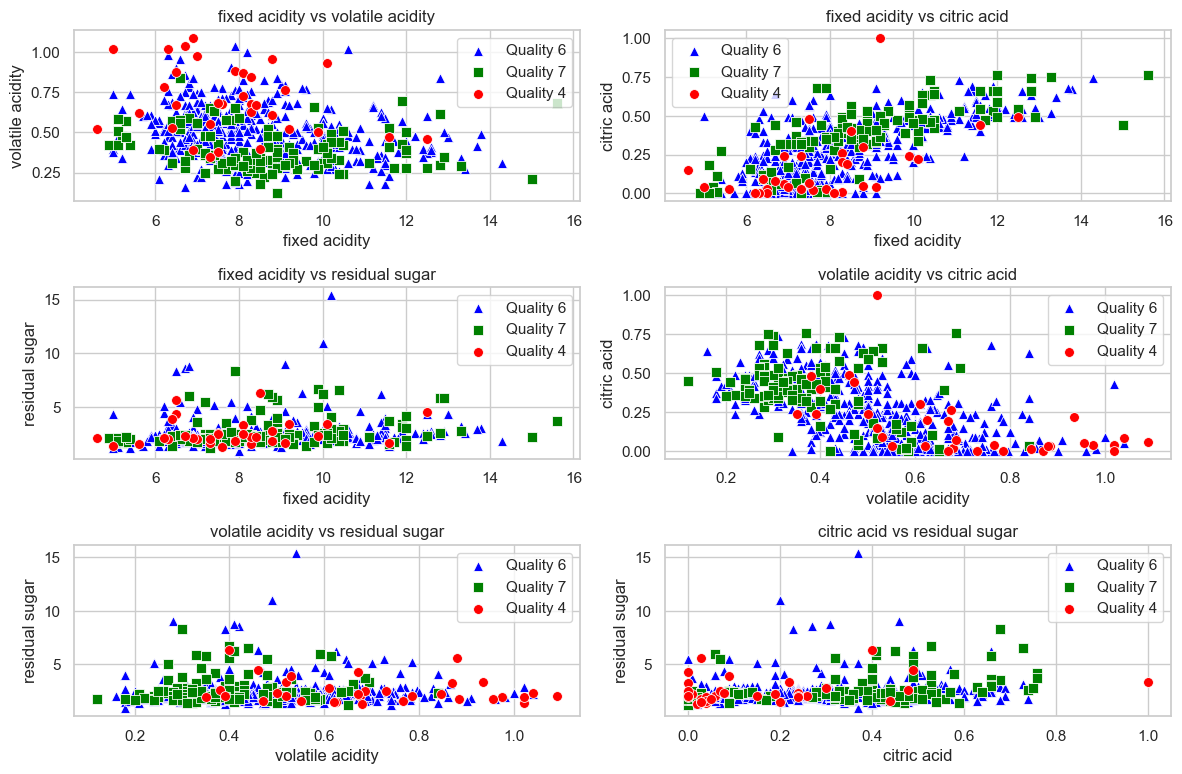

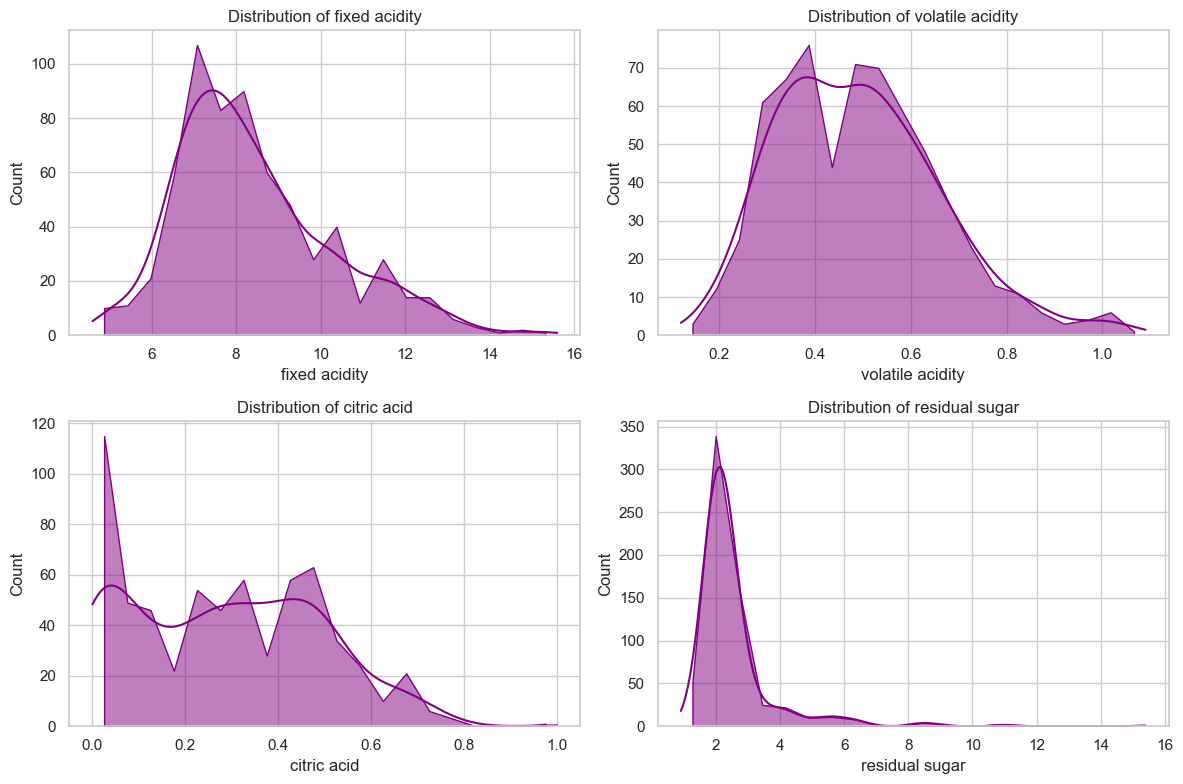


Pearson Correlation Matrix (All Data):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            1.0000           -0.2784       0.6894          0.1548
volatile acidity        -0.2784            1.0000      -0.5771         -0.0046
citric acid              0.6894           -0.5771       1.0000          0.1775
residual sugar           0.1548           -0.0046       0.1775          1.0000

Pearson P-values (All Data):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            0.0000             0.000          0.0          0.0001
volatile acidity         0.0000             0.000          0.0          0.9080
citric acid              0.0000             0.000          0.0          0.0000
residual sugar           0.0001             0.908          0.0          0.0000

Spearman Correlation Matrix (All Data):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity       

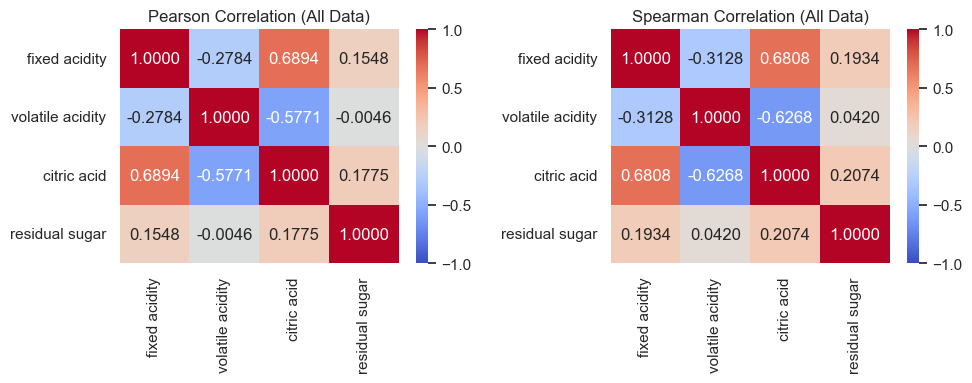


Pearson Correlation Matrix (Quality 6):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            1.0000           -0.2757       0.6870          0.1227
volatile acidity        -0.2757            1.0000      -0.5702          0.0178
citric acid              0.6870           -0.5702       1.0000          0.0912
residual sugar           0.1227            0.0178       0.0912          1.0000

Pearson P-values (Quality 6):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            0.0000            0.0000         0.00          0.0083
volatile acidity         0.0000            0.0000         0.00          0.7031
citric acid              0.0000            0.0000         0.00          0.0500
residual sugar           0.0083            0.7031         0.05          0.0000

Spearman Correlation Matrix (Quality 6):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity    

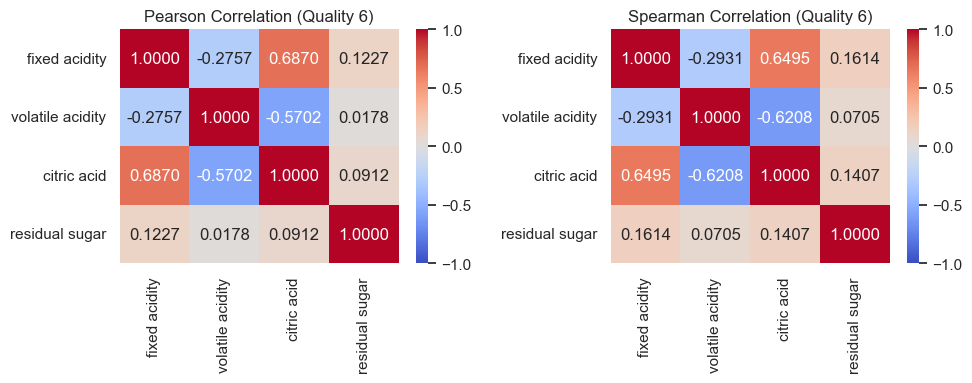


Pearson Correlation Matrix (Quality 7):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            1.0000           -0.1678       0.7179          0.1979
volatile acidity        -0.1678            1.0000      -0.3971          0.1049
citric acid              0.7179           -0.3971       1.0000          0.3375
residual sugar           0.1979            0.1049       0.3375          1.0000

Pearson P-values (Quality 7):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            0.0000            0.0451          0.0          0.0178
volatile acidity         0.0451            0.0000          0.0          0.2126
citric acid              0.0000            0.0000          0.0          0.0000
residual sugar           0.0178            0.2126          0.0          0.0000

Spearman Correlation Matrix (Quality 7):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity    

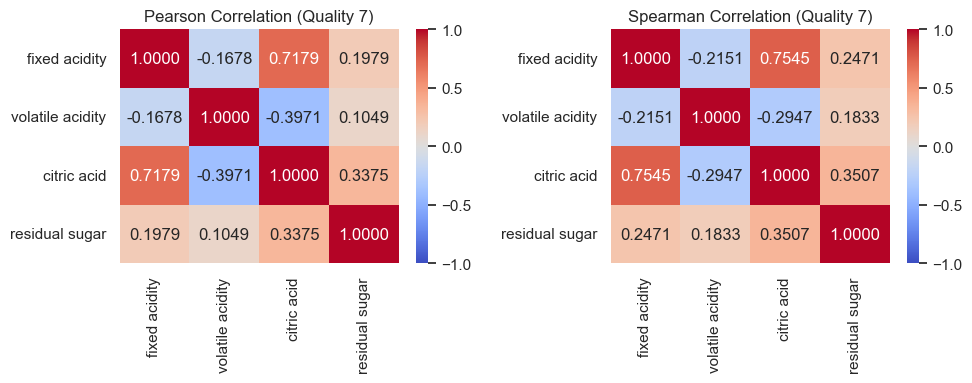


Pearson Correlation Matrix (Quality 4):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            1.0000           -0.2604       0.5134          0.1709
volatile acidity        -0.2604            1.0000      -0.5671         -0.1934
citric acid              0.5134           -0.5671       1.0000          0.2770
residual sugar           0.1709           -0.1934       0.2770          1.0000

Pearson P-values (Quality 4):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity            0.0000            0.1433       0.0022          0.3418
volatile acidity         0.1433            0.0000       0.0006          0.2808
citric acid              0.0022            0.0006       0.0000          0.1187
residual sugar           0.3418            0.2808       0.1187          0.0000

Spearman Correlation Matrix (Quality 4):
                  fixed acidity  volatile acidity  citric acid  residual sugar
fixed acidity    

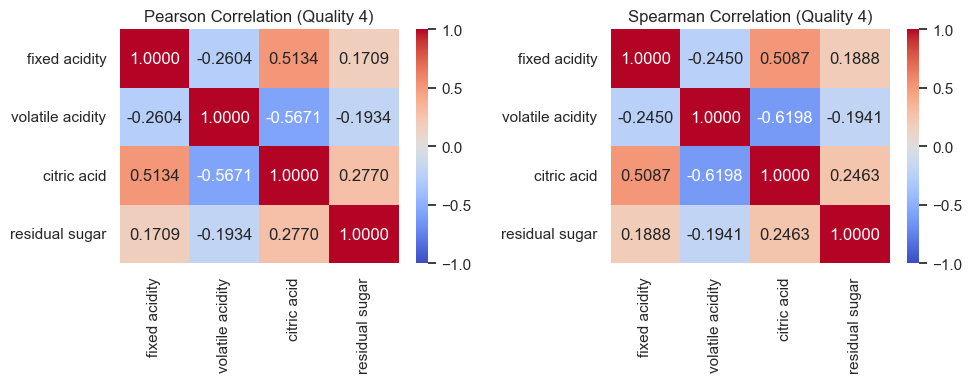

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from scipy.stats import pearsonr, spearmanr

%matplotlib inline

df = pd.read_csv('filtered_WineQT.csv')

class_styles = {
    4: {'color': 'red', 'marker': 'o'},
    6: {'color': 'blue', 'marker': '^'},
    7: {'color': 'green', 'marker': 's'}
}

sns.set_theme(style="whitegrid")

selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar']
pairs = list(itertools.combinations(selected_features, 2))

# Диаграммы рассеяния для всех пар признаков
plt.figure(figsize=(12, 10))
for i, (x_feature, y_feature) in enumerate(pairs, 1):
    plt.subplot(len(pairs) // 2 + 1, 2, i)
    for quality in df['quality'].unique():
        subset = df[df['quality'] == quality]
        sns.scatterplot(data=subset, x=x_feature, y=y_feature, 
                        color=class_styles[quality]['color'], 
                        marker=class_styles[quality]['marker'], 
                        label=f'Quality {quality}', s=50)
    plt.title(f'{x_feature} vs {y_feature}')
plt.tight_layout()
plt.show()

# Гистограммы распределения признаков
plt.figure(figsize=(12, 8))
for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=feature, bins=20,
                 kde=True, color='purple', alpha=0.5, 
                 element='poly')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

def compute_correlations(data, features, method='pearson'):
    corr_matrix = pd.DataFrame(index=features, columns=features)
    pval_matrix = pd.DataFrame(index=features, columns=features)
    
    for f1, f2 in itertools.combinations(features, 2):
        if method == 'pearson':
            corr, pval = pearsonr(data[f1], data[f2])
        elif method == 'spearman':
            corr, pval = spearmanr(data[f1], data[f2])
        corr_matrix.loc[f1, f2] = corr
        corr_matrix.loc[f2, f1] = corr
        pval_matrix.loc[f1, f2] = pval
        pval_matrix.loc[f2, f1] = pval
    
    # Заполняем диагональ (корреляция признака с самим собой)
    for f in features:
        corr_matrix.loc[f, f] = 1.0
        pval_matrix.loc[f, f] = 0.0
    
    return corr_matrix.astype(float), pval_matrix.astype(float)

pearson_corr, pearson_pval = compute_correlations(df, selected_features, method='pearson')
spearman_corr, spearman_pval = compute_correlations(df, selected_features, method='spearman')

print("\nPearson Correlation Matrix (All Data):")
print(pearson_corr.round(4))
print("\nPearson P-values (All Data):")
print(pearson_pval.round(4))
print("\nSpearman Correlation Matrix (All Data):")
print(spearman_corr.round(4))
print("\nSpearman P-values (All Data):")
print(spearman_pval.round(4))

# Тепловые карты корреляций для всего датасета
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.4f')
plt.title('Pearson Correlation (All Data)')
plt.subplot(1, 2, 2)
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.4f')
plt.title('Spearman Correlation (All Data)')
plt.tight_layout()
plt.show()

# Вычисление и вывод корреляций для каждого класса
for quality in df['quality'].unique():
    subset = df[df['quality'] == quality]
    pearson_corr, pearson_pval = compute_correlations(subset, selected_features, method='pearson')
    spearman_corr, spearman_pval = compute_correlations(subset, selected_features, method='spearman')
    
    print(f"\n{'='*50}")
    print(f"Pearson Correlation Matrix (Quality {quality}):")
    print(pearson_corr.round(4))
    print(f"\nPearson P-values (Quality {quality}):")
    print(pearson_pval.round(4))
    print(f"\nSpearman Correlation Matrix (Quality {quality}):")
    print(spearman_corr.round(4))
    print(f"\nSpearman P-values (Quality {quality}):")
    print(spearman_pval.round(4))
    
    # Тепловые карты для каждого класса
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.4f')
    plt.title(f'Pearson Correlation (Quality {quality})')
    plt.subplot(1, 2, 2)
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.4f')
    plt.title(f'Spearman Correlation (Quality {quality})')
    plt.tight_layout()
    plt.show()

# [5]

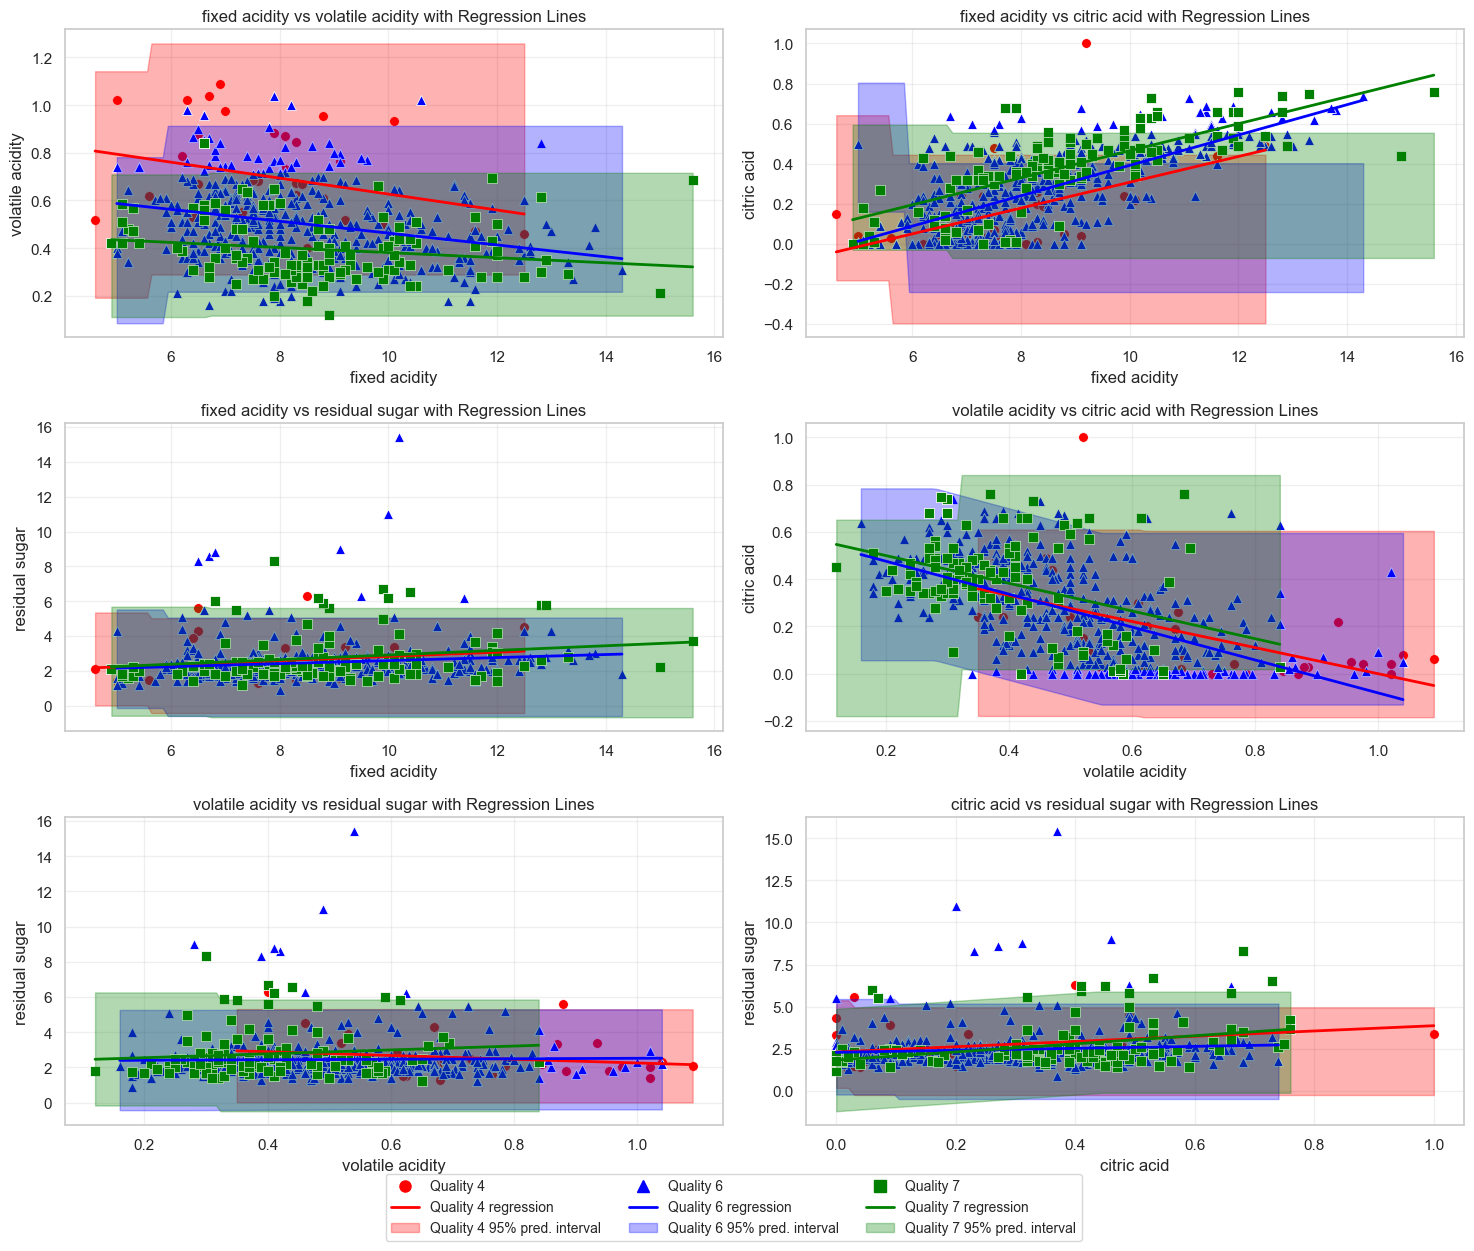

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import numpy as np
from sklearn.linear_model import LinearRegression

%matplotlib inline

df = pd.read_csv('filtered_WineQT.csv')

class_styles = {
    4: {'color': 'red', 'marker': 'o', 'label': 'Quality 4'},
    6: {'color': 'blue', 'marker': '^', 'label': 'Quality 6'},
    7: {'color': 'green', 'marker': 's', 'label': 'Quality 7'}
}

sns.set_theme(style="whitegrid")

selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar']
pairs = list(itertools.combinations(selected_features, 2))

def add_regression_line(ax, x_data, y_data, color, label, alpha=0.3, show_regression_label=False, show_interval_label=False):
    if len(x_data) < 2:
        return None, None  # Возвращаем None, если нет данных для регрессии
    
    # Подготовка данных как одномерных массивов
    x = x_data.values.flatten()
    y = y_data.values.flatten()
    
    # Линейная регрессия
    model = LinearRegression()
    X = x.reshape(-1, 1)
    model.fit(X, y)
    
    # Создание точек для плавной линии
    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)
    
    # Расчет предсказательных интервалов
    y_pred = model.predict(X)
    residuals = y - y_pred
    mse = np.mean(residuals**2)
    
    # Стандартная ошибка предсказания
    n = len(y)
    X_design = np.column_stack([np.ones(n), x])  # Дизайн-матрица для линейной регрессии
    H = X_design @ np.linalg.inv(X_design.T @ X_design) @ X_design.T  # Матрица "шляпы"
    se_pred = np.sqrt(mse * (1 + np.diag(H)))
    
    # 95% предсказательные интервалы
    t_critical = 2.262  # приблизительно для t-распределения при df≈30
    y_lower = y_pred - t_critical * se_pred
    y_upper = y_pred + t_critical * se_pred
    
    # Интерполяция интервалов для отображения на линии
    x_line_flat = x_line.flatten()
    y_lower_line = np.interp(x_line_flat, x, y_lower)
    y_upper_line = np.interp(x_line_flat, x, y_upper)
    
    # Построение линий БЕЗ добавления в легенду
    line_handle, = ax.plot(x_line_flat, y_line, color=color, linewidth=2, 
                          label=None)  # label=None, чтобы не добавлять в легенду
    interval_handle = ax.fill_between(x_line_flat, y_lower_line, y_upper_line, 
                                     color=color, alpha=alpha, label=None)  # label=None
    
    # Возвращаем handles для ручного управления легендой
    return line_handle, interval_handle

# Создание единой легенды для всех графиков
def create_legend_handles():
    handles = []
    labels = []
    for quality in sorted(class_styles.keys()):
        style = class_styles[quality]
        # Создаем placeholder для точки
        point_handle, = plt.plot([], [], color=style['color'], marker=style['marker'], 
                                linestyle='', markersize=8, label=style['label'])
        # Создаем placeholder для линии регрессии
        line_handle, = plt.plot([], [], color=style['color'], linewidth=2, 
                               label=f'{style["label"]} regression')
        # Создаем placeholder для интервала (используем patch)
        from matplotlib.patches import Patch
        interval_patch = Patch(color=style['color'], alpha=0.3, 
                              label=f'{style["label"]} 95% pred. interval')
        
        handles.extend([point_handle, line_handle, interval_patch])
        labels.extend([style['label'], f'{style["label"]} regression', 
                      f'{style["label"]} 95% pred. interval'])
    
    return handles, labels

# Диаграммы рассеяния с линиями регрессии для всех пар признаков
fig, axes = plt.subplots((len(pairs) + 1) // 2, 2, figsize=(15, 12))
if len(pairs) == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Строим все графики без легенд
for i, (x_feature, y_feature) in enumerate(pairs):
    ax = axes[i]
    
    # Построение точек для каждого класса
    for quality in sorted(class_styles.keys()):  # Используем только выбранные классы
        subset = df[df['quality'] == quality]
        if len(subset) > 0:
            style = class_styles[quality]
            # Строим scatterplot БЕЗ label (чтобы не засорять легенду)
            sns.scatterplot(data=subset, x=x_feature, y=y_feature, 
                            color=style['color'], 
                            marker=style['marker'], 
                            label='_nolegend_',  # Скрываем из легенды
                            s=50, ax=ax)
            
            # Добавление линии регрессии для этого класса
            add_regression_line(ax, subset[x_feature], subset[y_feature], 
                              style['color'], 
                              style['label'], show_regression_label=False, 
                              show_interval_label=False)
    
    ax.set_title(f'{x_feature} vs {y_feature} with Regression Lines')
    ax.grid(True, alpha=0.3)

# Удаление пустых subplot'ов
for j in range(len(pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Добавляем общую легенду внизу
handles, labels = create_legend_handles()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), 
           ncol=3, fontsize='small')
plt.show()


# [6]

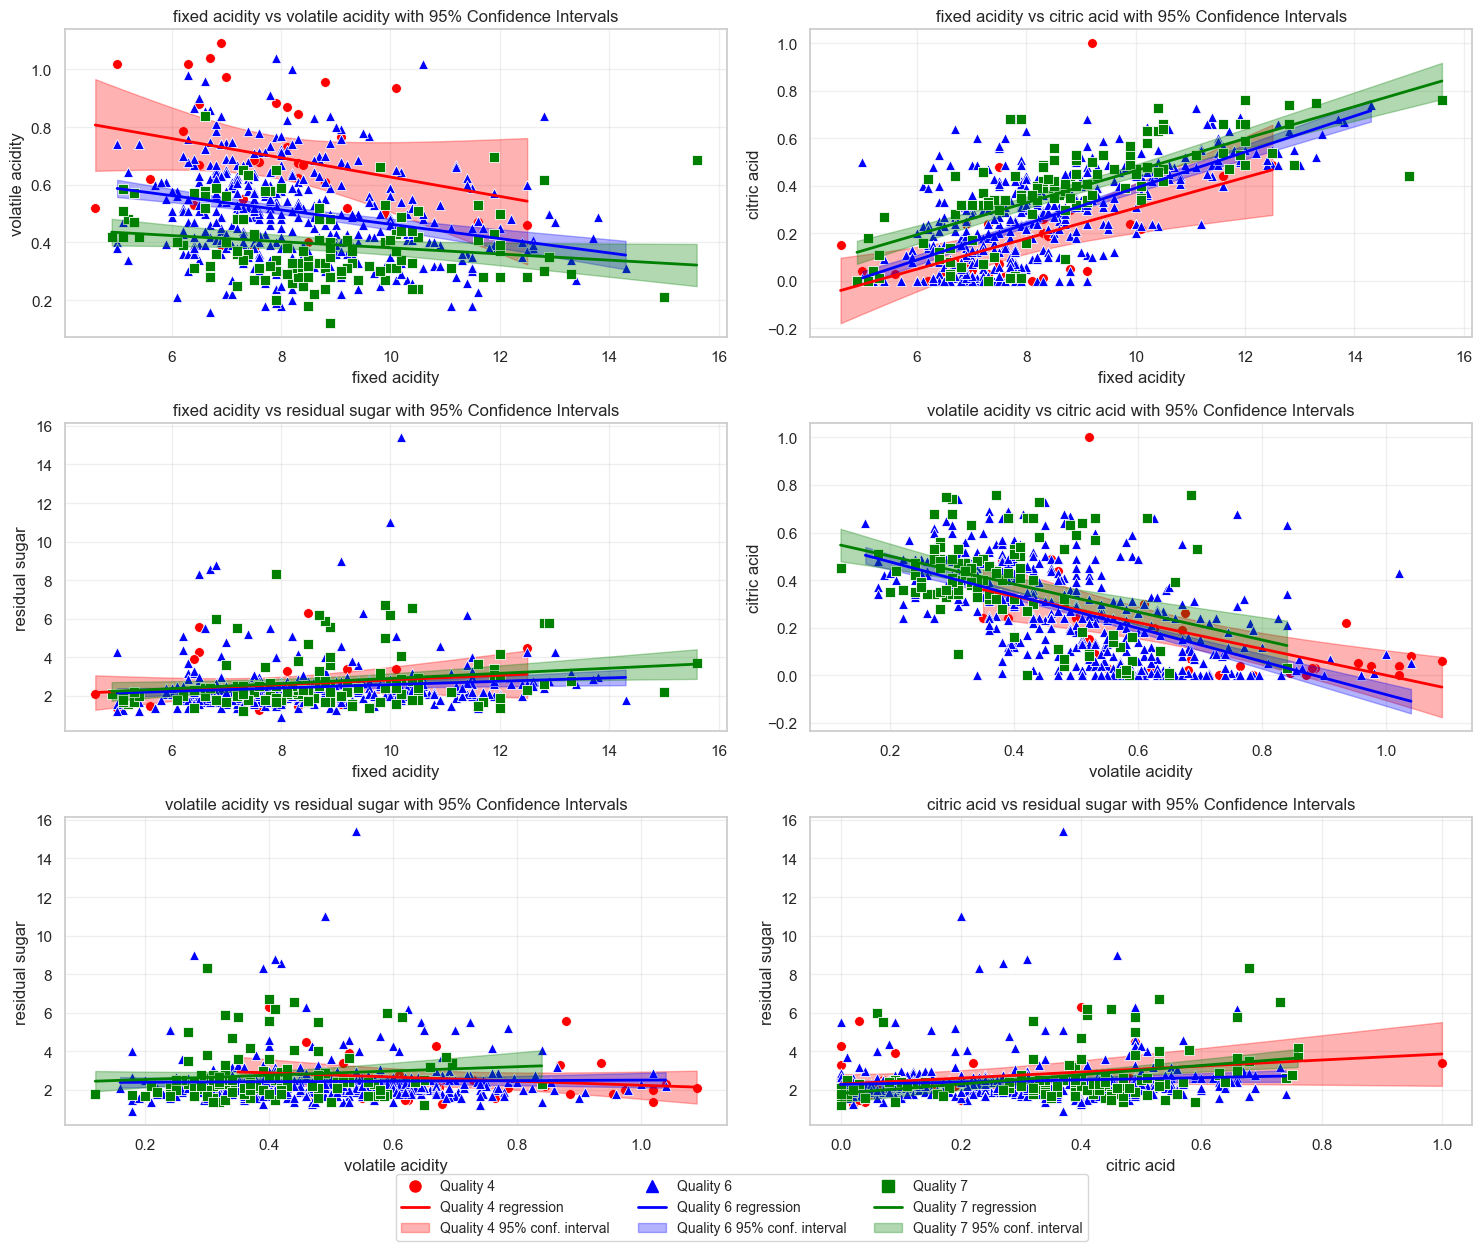

In [20]:
# Импорты для регрессии
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from scipy.stats import pearsonr, spearmanr
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats

# Настройка matplotlib для отображения графиков в Jupyter
%matplotlib inline

# Загрузка отфильтрованного датасета
df = pd.read_csv('filtered_WineQT.csv')

# Стили для выбранных классов (только 4, 6, 7)
class_styles = {
    4: {'color': 'red', 'marker': 'o', 'label': 'Quality 4'},
    6: {'color': 'blue', 'marker': '^', 'label': 'Quality 6'},
    7: {'color': 'green', 'marker': 's', 'label': 'Quality 7'}
}

# Настройка стиля seaborn
sns.set_theme(style="whitegrid")

# Выбранные признаки
selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar']
pairs = list(itertools.combinations(selected_features, 2))

# Функция для построения линейной регрессии с ДОВЕРИТЕЛЬНЫМИ интервалами (95% confidence bands)
def add_regression_line(ax, x_data, y_data, color, label, alpha=0.3, show_regression_label=False, show_interval_label=False):
    if len(x_data) < 2:
        return None, None  # Возвращаем None, если нет данных для регрессии
    
    # Подготовка данных как одномерных массивов
    x = x_data.values.flatten()
    y = y_data.values.flatten()
    
    # Линейная регрессия
    model = LinearRegression()
    X = x.reshape(-1, 1)
    model.fit(X, y)
    
    # Создание точек для плавной линии
    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)
    
    # РАСЧЕТ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ (confidence intervals)
    # Статистические параметры
    n = len(y)
    k = 1  # количество предикторов (только X)
    df = n - k - 1  # степени свободы
    
    # Предсказания и остатки
    y_pred = model.predict(X)
    residuals = y - y_pred
    mse = np.mean(residuals**2)
    
    # Стандартная ошибка для коэффициентов
    X_design = np.column_stack([np.ones(n), x])  # Дизайн-матрица
    XTX_inv = np.linalg.inv(X_design.T @ X_design)
    se_b = np.sqrt(mse * np.diag(XTX_inv))
    
    # t-критическое значение для 95% доверительного интервала
    t_critical = stats.t.ppf(0.975, df)  # 97.5% квантиль для двухстороннего интервала
    
    # Стандартная ошибка среднего предсказания для доверительных интервалов
    # Для каждого нового x: se_mean = sqrt(mse * x_new^T * (X^T X)^(-1) * x_new)
    X_line_design = np.column_stack([np.ones(len(x_line)), x_line.flatten()])
    se_mean_line = np.sqrt(mse * np.diag(X_line_design @ XTX_inv @ X_line_design.T))
    
    # Доверительные интервалы для среднего (не для отдельных предсказаний)
    y_lower_ci = y_line.flatten() - t_critical * se_mean_line
    y_upper_ci = y_line.flatten() + t_critical * se_mean_line
    
    # Построение линий БЕЗ добавления в легенду
    line_handle, = ax.plot(x_line.flatten(), y_line.flatten(), color=color, linewidth=2, 
                          label=None)  # label=None, чтобы не добавлять в легенду
    interval_handle = ax.fill_between(x_line.flatten(), y_lower_ci, y_upper_ci, 
                                     color=color, alpha=alpha, label=None)  # label=None
    
    # Возвращаем handles для ручного управления легендой
    return line_handle, interval_handle

# Создание единой легенды для всех графиков
def create_legend_handles():
    handles = []
    labels = []
    for quality in sorted(class_styles.keys()):
        style = class_styles[quality]
        # Создаем placeholder для точки
        point_handle, = plt.plot([], [], color=style['color'], marker=style['marker'], 
                                linestyle='', markersize=8, label=style['label'])
        # Создаем placeholder для линии регрессии
        line_handle, = plt.plot([], [], color=style['color'], linewidth=2, 
                               label=f'{style["label"]} regression')
        # Создаем placeholder для интервала (используем patch)
        from matplotlib.patches import Patch
        interval_patch = Patch(color=style['color'], alpha=0.3, 
                              label=f'{style["label"]} 95% conf. interval')
        
        handles.extend([point_handle, line_handle, interval_patch])
        labels.extend([style['label'], f'{style["label"]} regression', 
                      f'{style["label"]} 95% conf. interval'])
    
    return handles, labels

# Диаграммы рассеяния с линиями регрессии и ДОВЕРИТЕЛЬНЫМИ интервалами
fig, axes = plt.subplots((len(pairs) + 1) // 2, 2, figsize=(15, 12))
if len(pairs) == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Строим все графики без легенд
for i, (x_feature, y_feature) in enumerate(pairs):
    ax = axes[i]
    
    # Построение точек для каждого класса
    for quality in sorted(class_styles.keys()):  # Используем только выбранные классы
        subset = df[df['quality'] == quality]
        if len(subset) > 0:
            style = class_styles[quality]
            # Строим scatterplot БЕЗ label (чтобы не засорять легенду)
            sns.scatterplot(data=subset, x=x_feature, y=y_feature, 
                            color=style['color'], 
                            marker=style['marker'], 
                            label='_nolegend_',  # Скрываем из легенды
                            s=50, ax=ax)
            
            # Добавление линии регрессии с доверительными интервалами для этого класса
            add_regression_line(ax, subset[x_feature], subset[y_feature], 
                              style['color'], 
                              style['label'], show_regression_label=False, 
                              show_interval_label=False)
    
    ax.set_title(f'{x_feature} vs {y_feature} with 95% Confidence Intervals')
    ax.grid(True, alpha=0.3)

# Удаление пустых subplot'ов
for j in range(len(pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Добавляем общую легенду внизу
handles, labels = create_legend_handles()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), 
           ncol=3, fontsize='small')
plt.show()